In [ ]:
import conntility
import numpy
import pandas
from pathlib import Path


from scipy.spatial import distance

from matplotlib import pyplot as plt


root = Path("/Users/mwr/Documents/artefacts/connectomes/Human connectivity paper")
# root = Path("/Users/mwr/Documents/artefacts/connectomes")

dataset = "human_em"

# Load the data
if dataset == "human_model":
    fn = root / "Human_NEWfunct_conmat_filtered_compressed.h5"
    M = conntility.ConnectivityMatrix.from_h5(fn)
elif dataset == "human_em":
    fn = root / "Shapson_Coe_et_al_human_all_somas.h5"
    M = conntility.ConnectivityMatrix.from_h5(fn, "compressed")
elif dataset == "mouse_em":
    fn = root / "microns_mm3_connectome_v1181.h5"
    M = conntility.ConnectivityMatrix.from_h5(fn, "condensed")
elif dataset == "rat_model":
    fn = root / "Rat_623um_squared_struc_conmat_filtered_compressed.h5"
    M = conntility.ConnectivityMatrix.from_h5(fn)


Dataset-dependent pre-processing.

This turns the respective networks into virtual slices that we can experiment on.

In [54]:
if dataset == "human_em":
    # Shapson-Coe

    # STEP 1: Only neurons. Filter out non-neurons
    types_of_interest = [
        "PYRAMIDAL",
        "INTERNEURON",
        "SPINY_ATYPICAL",
        "UNCLASSIFIED_NEURON",
        "SPINY_STELLATE"
    ]
    M = M.index("celltype").isin(types_of_interest)

    # STEP 2: Convert from voxel indices to coordinates in um
    xyz = ["x", "y", "z"]
    full_res = numpy.array([ 8, 8, 33 ]) # voxel resultion in nm

    for _col, _fac in zip(xyz, full_res):
        M.add_vertex_property(_col + "_um", M.vertices[_col].values * _fac / 1000)
    xyz = ["x_um", "y_um", "z_um"]

    # STEP 4: Only layer 2/3
    M = M.index("layer").isin(["Layer 2", "Layer 3"])

    # Dataset already is a slice. With x and y as main coordinates and z the 200 um slice thickness
    xy_slice = ["x_um", "y_um"]

if dataset == "human_model":
    # HUMAN MODEL
    # STEP 1: Only layers 2/3.
    types_of_interest = [
        "L2_PTPC",
        "L3_PTPC",
        "L3_STPC",
        "L3_PC"
    ]
    M = M.index("mtype").isin(types_of_interest)
    # STEP 2:Create slice
    M = M.slice(0.0, 0.0, 150.0, columns_slice=["x", "z"], column_y="y")
    xyz = ["x", "y", "z"]
    xy_slice = ["slice_x", "slice_y"]

if dataset == "mouse_em":
    # STEP 1: Only layers 2/3.
    types_of_interest = ["L2a", "L2b", "L2c", "L3a", "L3b"]
    M = M.index("cell_type").isin(types_of_interest)
    # STEP 2: Convert coordinates from nm to um
    for _coord in ["x", "y", "z"]:
        M.add_vertex_property(_coord, M.vertices[_coord + "_nm"].values / 1000)
    # STEP 3:Create slice
    # In Microns the y-axis is sufficently close to vertical.
    M = M.slice(0.0, 0.0, 150.0, columns_slice=["x", "z"], column_y="y")
    
    xy_slice = ["slice_x", "slice_y"]

if dataset == "rat_model":
    # HUMAN MODEL
    # STEP 1: Only EXC and only layers 2/3.
    M = M.index("synapse_class").eq("EXC")
    M = M.index("layer").isin(["2", "3"])
    # STEP 2:Create slice
    M = M.slice(0.0, 0.0, 150.0, columns_slice=["x", "z"], column_y="y")
    xyz = ["x", "y", "z"]
    xy_slice = ["slice_x", "slice_y"]

In [ ]:
def bootstrapping_overexpression(nrec, ncon, npairs):
    nrec = numpy.array(nrec)
    ncon = numpy.array(ncon)
    npairs = numpy.array(npairs)

    rnd = numpy.random.choice(len(nrec), 200 * 1000).reshape((200, 1000))

    pcon = ncon[rnd].sum(axis=1) / npairs[rnd].sum(axis=1)
    prec = nrec[rnd].sum(axis=1) / npairs[rnd].sum(axis=1)

    over = prec / (pcon ** 2)
    return over.mean(), over.std()

scales = [20.0, 50.0, 100.0, 150.0, 200.0, 250.0, 300.0, 350.0, 400.0]
res = []
for scale in scales:
    print(scale)
    mv_cv = numpy.array([[scale, 0.0],
                        [0.0, scale]]) ** 2

    npairs = []
    ncon = []
    nrec = []
    npatch = 12

    for _ in range(2000):
        mv_mn = numpy.random.rand(2) * 300 - 150
        try:
            smpl = M.patch_sample(npatch, mv_mn, mv_cv, columns_xy=xy_slice)
            npairs.append(len(smpl) * (len(smpl) - 1))
            ncon.append(len(smpl.edges))
            nrec.append(len(smpl.to_reciprocal().edges))
        except:
            pass

    res.append(bootstrapping_overexpression(nrec, ncon, npairs))

res = numpy.vstack(res)

20.0
50.0
100.0
150.0
200.0
250.0
300.0
350.0
400.0


Non-sampled overexpression.

Part 1: Compared to ER

In [56]:
ttl_npairs = len(M) * (len(M) - 1)
ttl_ncon = len(M.edges)
ttl_nrec = len(M.to_reciprocal().edges)

ttl_pcon = ttl_ncon / ttl_npairs
ttl_prec = ttl_nrec / ttl_npairs

ttl_over = ttl_prec / (ttl_pcon ** 2)

Part 2: Compared to a fitted distance-dependent model

In [57]:
import connalysis

mdl = connalysis.modelling.conn_prob_2nd_order_model(M.matrix.tocsc().astype(bool), M.vertices, coord_names=xy_slice)

Ctrl = connalysis.randomization.run_DD2_model(M.matrix, M.vertices, model_params_dd2=mdl, coord_names=xy_slice)
Ctrl = conntility.ConnectivityMatrix(Ctrl, vertex_properties=M._vertex_properties)
Ctrl_r = Ctrl.to_reciprocal()   

ttl_dd_over = ttl_nrec / len(Ctrl_r.edges)

[2025-05-23 14:13:42,219] INFO: Running order-2 model building {'coord_names': ['slice_x', 'slice_y'], 'model_dir': None, 'data_dir': None, 'plot_dir': None, 'do_plot': False, 'part_idx': None, 'sample_seed': None}...
[2025-05-23 14:13:42,276] INFO: Extracting 1-dimensional (10) connection probabilities...


[2025-05-23 14:13:44,430] INFO: MODEL FIT: f(x) = 1.049121 * exp(-0.004929 * x)


[2025-05-23 14:13:44,447] INFO: Run DD2 model with parameters: 
      exp_model_scale  exp_model_exponent
seed                                     
None         1.049121            0.004929


(0.8, 1.971881804376671)

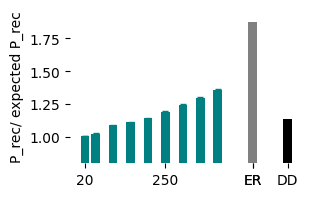

In [58]:
fig = plt.figure(figsize=(3, 2))
ax = fig.gca()

bar_loc_er_ctrl = scales[-1] + 100
bar_loc_dd_ctrl = scales[-1] + 200

ax.bar(scales, res[:, 0], yerr=res[:, 1], capsize=2, ecolor="teal", label='Error bars', color="teal")
ax.bar(scales, res[:, 0], width=25, color="teal")
ax.bar([bar_loc_er_ctrl], [ttl_over], width=25, color="grey")
ax.bar([bar_loc_dd_ctrl], [ttl_dd_over], width=25, color="black")
ax.set_xticks([20, 250, 500, bar_loc_er_ctrl, bar_loc_dd_ctrl])
ax.set_xticklabels([20, 250, 500, "ER", "DD"])
ax.set_ylabel("P_rec/ expected P_rec")
ax.set_frame_on(False)
ax.set_ylim([0.8, ax.get_ylim()[1]])